### Performance evaluation on the HSDM data set ###

In [1]:
import sys
import os
import numpy as np
import json
import pandas as pd
import logging
from pathlib import Path
from matplotlib import pyplot as plt
from matplotlib.patches import Rectangle
from sklearn import metrics

logger = logging.getLogger(__name__)

# PyTorch
import torch
from torchvision import ops

%load_ext autoreload
%autoreload 2
import computervision
from computervision.imageproc import is_image, ImageData, clipxywh, xyxy2xywh, xywh2xyxy, plot_boxes
from computervision.datasets import DETRdataset, get_gpu_info
from computervision.transformations import AugmentationTransform
from computervision.performance import DetectionMetrics
from computervision.inference import DETRInference

print(f'Project version: {computervision.__version__}')
print(f'Authors: {computervision.__authors__}')
print(f'Python version:  {sys.version}')

Project version: v0.0.2
Authors: The Core for Computational Biomedicine at Harvard Medical School
https://dbmi.hms.harvard.edu/about-dbmi/core-computational-biomedicine
Python version:  3.12.3 (main, Jun 18 2025, 17:59:45) [GCC 13.3.0]


In [2]:
# Check GPU availability
device, device_str = get_gpu_info()
print(f'Current device {device}')

CUDA available: True
Number of GPUs found:  1
Current device ID: 0
GPU device name:   NVIDIA GeForce RTX 3060 Laptop GPU
PyTorch version:   2.8.0a0+34c6371d24.nv25.08
CUDA version:      13.0
CUDNN version:     91200
Device for model training/inference: cuda:0
Current device cuda:0


In [6]:
# Dataset and image files
dataset_name = 'dataset_object_240921'
image_dir = os.path.join(os.environ.get('DATA'), dataset_name)
df_file_name = 'objectdata_240921_clean_ide_dset.parquet'
df_file = os.path.join(image_dir, df_file_name)
df = pd.read_parquet(df_file)
display(df.head(2))

pos_col = 'pos'
bbox_col = 'bbox'
dset_col = 'dset'
file_col = 'file_name'
dset_list = ['val', 'test']

# Filter the test data
df = df.loc[(~df[pos_col].isnull()) & (df[dset_col].isin(['val', 'test']))]
n_images = len(df[file_col].unique())
n_annotations = df.shape[0]
print(f'Images:      {n_images}')
print(f'Annotations: {n_annotations}')

# Model checkpoint
model_name = 'rtdetr_dtx_251012_02'
checkpoint = 'checkpoint-2000'
batch_size = 16
model_dir = os.path.join(os.environ.get('DATA'), 'model', model_name)
checkpoint_dir = os.path.join(model_dir, checkpoint)
detr = DETRInference(device=device, checkpoint_path=checkpoint_dir, batch_size=batch_size)

# Load the model configuration
config_file_name = f'{model_name}.json'
config_file = os.path.join(model_dir, config_file_name)
with open(config_file, mode='r') as fl:
    config = json.load(fl)
print(list(config.keys()))
model_info = config.get('model_info')

,file_name,width,height,bbox,pos,disease,dset
0,0060bce2_20210430_02.png,1200,854,"[204, 0, 620, 443]",14,unstable,val
1,0060bce2_20210430_02.png,1200,854,"[715, 409, 485, 445]",18,stable,val


Images:      639
Annotations: 1129
['model_info', 'id2label', 'training_args', 'processor_params', 'bbox_format']


### Run predictions on the data set for a given threshold value ###

In [7]:
# Set the prediction threshold
thr = 0.05

# Create a data set with the test data
bbox_format = {'format': 'coco',
               'label_fields': ['tooth_position'],
               'clip': True,
               'min_area': 10000}

im_width = model_info.get('im_width')
im_height = model_info.get('im_height')

val_transforms = AugmentationTransform(im_width=im_width, 
                                       im_height=im_height).\
    get_transforms(name='val')

dataset = DETRdataset(data=df.copy(), 
                      image_processor=detr.processor,
                      image_dir=image_dir,
                      file_name_col=file_col,
                      label_id_col=None,
                      bbox_col=None,
                      bbox_format=bbox_format,
                      transforms=val_transforms)

# Run the predictions on the data set
pred_df = detr.predict_on_dataset(dataset, threshold=0.05)

Predicting batch 10 of 40.
Predicting batch 20 of 40.
Predicting batch 30 of 40.
Predicting batch 40 of 40.


In [8]:
# Add the file names to the data frame
file_list = list(df[file_col].unique())
file2id = dict(zip(file_list, range(len(file_list))))
id2file = {int(image_id): file for file, image_id in file2id.items()}
pred_df[file_col] = pred_df['image_id'].apply(lambda image_id: id2file.get(image_id))

# Add the labels to the data frame
id2label = config.get('id2label')
id2label = {int(category_id): int(label) for category_id, label in id2label.items()}
pred_df[pos_col] = pred_df['category_id'].apply(lambda category_id: id2label.get(category_id))

# Find the images with no predictions
pred_df_empty = pred_df.loc[pred_df[pos_col].isnull(), file_col].unique()

# Keep a data frame with the images that had predicted bounding boxes
predicted_df = pred_df.loc[~pred_df[pos_col].isnull()]

print(f'Images in data set:         {len(dataset)}')
print(f'Images without predictions: {len(pred_df_empty)}')
print(f'Images with predictions:    {len(predicted_df[file_col].unique())}')

display(pred_df.head(5))

Images in data set:         639
Images without predictions: 0
Images with predictions:    639


,image_id,image_width,image_height,batch,category_id,bbox,score,area,file_name,pos
0,0,1200,854,0,14,"[596, 0, 351, 291]",0.189151,102141,0060bce2_20210430_02.png,15
1,0,1200,854,0,15,"[870, 0, 327, 92]",0.182009,30084,0060bce2_20210430_02.png,16
2,0,1200,854,0,13,"[196, 0, 444, 310]",0.176075,137640,0060bce2_20210430_02.png,14
3,0,1200,854,0,17,"[716, 288, 438, 319]",0.119698,139722,0060bce2_20210430_02.png,18
4,0,1200,854,0,22,"[0, 370, 112, 237]",0.116305,26544,0060bce2_20210430_02.png,23


### Classify the detections: TP, FP, FN for all images ###

In [9]:
# Classify predictions for all images
iou_threshold = 0.2
pred_file_df_list = []
missed_file_df_list = []

for file_idx, file_name in enumerate(file_list):

    if (file_idx + 1) % 100 == 0:
        print(f'Loading image {file_idx +1} / {len(file_list)}')
    
    file_df = df.loc[df[file_col] == file_name]
    file = os.path.join(image_dir, file_name)
    # im = ImageData().load_image(file)
    # im = ImageData().np2color(im)
    
    im_height = file_df['height'].tolist()[0]
    im_width = file_df['width'].tolist()[0]
    
    bboxes = file_df[bbox_col].tolist()
    bboxes = [clipxywh(list(bbox), xlim=(0, im_width), ylim=(0, im_height)) for bbox in bboxes]
    labels = file_df[pos_col].tolist()
    
    file_pred_df = predicted_df.loc[predicted_df[file_col] == file_name]
    
    if len(file_pred_df) > 0:

        # Detections for this image
        file_pred_df = file_pred_df.astype({pos_col: int}) 
        pred_bboxes = file_pred_df[bbox_col].tolist()
        pred_bboxes = [clipxywh(list(bbox), xlim=(0, im_width), ylim=(0, im_height)) for bbox in pred_bboxes]
        pred_labels = file_pred_df[pos_col].tolist()
        pred_scores = file_pred_df['score'].tolist()
        
        # Classify predictions based on IoU
        dm = DetectionMetrics(im_width=im_width, im_height=im_height, bbox_format='xywh')
        pred_cl = dm.classify_predictions(true_labels=labels, 
                                          true_bboxes=bboxes, 
                                          pred_labels=pred_labels, 
                                          pred_bboxes=pred_bboxes, 
                                          iou_threshold=iou_threshold)

        pred_cl = pred_cl.assign(score=pred_scores, bbox=pred_bboxes)
        pred_cl = pred_cl.assign(iou_threshold=iou_threshold)
        pred_cl = pred_cl.rename(columns={'pred_label': pos_col})
        
        # Only consider those classes that were labeled in the image.
        # With this, we possibly remove correct predictions.
        # But without a complete ground truth data set, we just don't know.
        true_pred_cl = pred_cl.loc[pred_cl['pos'].isin(labels)]
        
        if len(true_pred_cl) > 0:
            
            true_pred_cl.insert(loc=0, column=file_col, value=file_name)
            pred_file_df_list.append(true_pred_cl)

        # False Negatives: Labels in the ground truth data that were not detected
        # We can determine the false negatives for those objects that were labeled
        missed = sorted(list(set(labels).difference(pred_labels)))
        missed_file_df = pd.DataFrame({pos_col: missed})
        
    else:
        
        # print(f'No predictions for image: {file_name}')
        missed_file_df = pd.DataFrame({pos_col: sorted(labels)})
    
    if len(missed_file_df) > 0:
        missed_file_df.insert(loc=0, column=file_col, value=file_name)
        missed_file_df_list.append(missed_file_df)

missed_df = pd.concat(missed_file_df_list, axis=0, ignore_index=True)
detected = pd.concat(pred_file_df_list, axis=0, ignore_index=True)
detected = detected.\
    sort_values(by=['pos', 'score'], ascending=False).\
    reset_index(drop=True)

Loading image 100 / 639
Loading image 200 / 639
Loading image 300 / 639
Loading image 400 / 639
Loading image 500 / 639
Loading image 600 / 639


### Precision - Recall ###

In [10]:
def precision_recall(data_df, classifications, label_col='pos'):
    """ Add precision and recall values to the detection classifications """
    # List of labels
    cl_list = sorted(list(classifications[label_col].unique()))
    pr_df_list = []    
    for cl in cl_list:
        # Total ground truth labels in data set for this class (TP + FN)
        n_cl = len(data_df.loc[data_df[label_col] == cl])
        # Sort the predictions for this class by descening score
        detected_cl = classifications.loc[classifications[label_col] == cl].\
            sort_values(by='score', ascending=False).\
            reset_index(drop=True)
        # Calculate precision-recall for each row
        # PRECISION : TP / (TP + FP)
        # RECALL: TP / (TP + FN)
        correct = detected_cl['TP'].tolist()
        detected_cl = detected_cl.assign(
            precision=[sum(correct[:i + 1])/(i + 1) for i in range(len(correct))],
            recall=[sum(correct[:i + 1])/n_cl for i in range(len(correct))])
        pr_df_list.append(detected_cl)
        pr_df = pd.concat(pr_df_list, axis=0, ignore_index=True)
    return pr_df

In [11]:
# EXAMPLE 
# https://jonathan-hui.medium.com/map-mean-average-precision-for-object-detection-45c121a31173
n_pos = 5
correct = [1, 1, 0, 0, 0, 1, 1, 0, 0, 1]
i = 1
prec = sum(correct[:i + 1])/(i + 1)
rec = sum(correct[:i + 1])/n_pos

print(f'Precision: {prec}')
print(f'Recall:    {rec}')

# For the entire series
precision = [sum(correct[:i + 1])/(i + 1) for i in range(len(correct))]
recall = [sum(correct[:i + 1])/n_pos for i in range(len(correct))]
print()
print(f'Precision: {precision}')
print(f'Recall:    {recall}')

Precision: 1.0
Recall:    0.4

Precision: [1.0, 1.0, 0.6666666666666666, 0.5, 0.4, 0.5, 0.5714285714285714, 0.5, 0.4444444444444444, 0.5]
Recall:    [0.2, 0.4, 0.4, 0.4, 0.4, 0.6, 0.8, 0.8, 0.8, 1.0]


### Calculate Average Precision: AUC of the P-R curve ###

In [12]:
# Calculate PR for the given IoU
# This needs to be run after the prediction in the entire test set are classified
data_df = df.copy()
classifications = detected.copy()

# A meaningful P-R curve requires a minimum number of detections
min_detections = 10

pr_df = precision_recall(data_df=data_df, 
                         classifications=classifications, 
                         label_col=pos_col)

pos_list = sorted(list(pr_df[pos_col].unique()))

auc_df_list = []

for p, pos in enumerate(pos_list):

    pr_pos = pr_df.loc[pr_df[pos_col] == pos]
    prec = pr_pos['precision'].tolist()
    rec = pr_pos['recall'].tolist()
    tp_list = pr_pos['TP'].tolist()
    tp = sum(tp_list)
    fp = len(tp_list) - sum(tp_list)

    # AUC makes sense only when we have enough data
    # Set the minimum number of values to 10!

    if len(rec) > min_detections: 
    
        auc = metrics.auc(x=rec, y=prec)
    
        # Collect some additional information
        positives = len(data_df.loc[data_df[pos_col] == pos])
        missed_pos = len(missed_df.loc[missed_df[pos_col] == pos])
    
        auc_dict = {'model': model_name,
                    'checkpoint': checkpoint,
                    'threshold': thr,
                    pos_col: pos,
                    'iou_threshold': iou_threshold,
                    'auc_pr': auc,
                    'total_pos': positives,
                    'tp': tp,
                    'fp': fp,
                    'missed': missed_pos}
    
        auc_df = pd.DataFrame(auc_dict, index=[p])
        auc_df_list.append(auc_df)

ap_df = pd.concat(auc_df_list, axis=0)
ap_df = ap_df.sort_values(by='auc_pr', ascending=False)

# Save this result
performance_dir = os.path.join(os.environ.get('DATA'), 'model', 'performance')
Path(performance_dir).mkdir(parents=True, exist_ok=True)

checkpoint_number = checkpoint.rsplit('-')[-1]
performance_file_name = f'{model_name}_{checkpoint_number}.parquet'
performance_file = os.path.join(performance_dir, performance_file_name)

print(f'Saving output to: {performance_file}')
ap_df.to_parquet(performance_file)

Saving output to: /app/data_model/model/performance/rtdetr_dtx_251012_02_2000.parquet


In [13]:
display(ap_df)

,model,checkpoint,threshold,pos,iou_threshold,auc_pr,total_pos,tp,fp,missed
8,rtdetr_dtx_251012_02,checkpoint-2000,0.05,10,0.2,0.604854,18,15,19,0
28,rtdetr_dtx_251012_02,checkpoint-2000,0.05,31,0.2,0.593125,40,31,61,2
25,rtdetr_dtx_251012_02,checkpoint-2000,0.05,28,0.2,0.591011,34,27,42,4
27,rtdetr_dtx_251012_02,checkpoint-2000,0.05,30,0.2,0.508521,56,38,23,7
13,rtdetr_dtx_251012_02,checkpoint-2000,0.05,15,0.2,0.490388,32,19,18,10
16,rtdetr_dtx_251012_02,checkpoint-2000,0.05,19,0.2,0.439164,58,36,35,12
7,rtdetr_dtx_251012_02,checkpoint-2000,0.05,9,0.2,0.376463,29,18,15,5
23,rtdetr_dtx_251012_02,checkpoint-2000,0.05,26,0.2,0.370178,26,19,61,4
6,rtdetr_dtx_251012_02,checkpoint-2000,0.05,8,0.2,0.362850,24,17,25,2
15,rtdetr_dtx_251012_02,checkpoint-2000,0.05,18,0.2,0.352337,36,23,44,3


### Visualizations ###

In [11]:
image_output_dir = os.path.join(os.environ.get('DATA'), 'model', 'images', 
                                f'{model_name}_{checkpoint_number}')
Path(image_output_dir).mkdir(parents=True, exist_ok=True)

# Filter some good predictions
images = detected.loc[detected['score'] > 0.12, 'file_name'].tolist()
print(len(images))

19


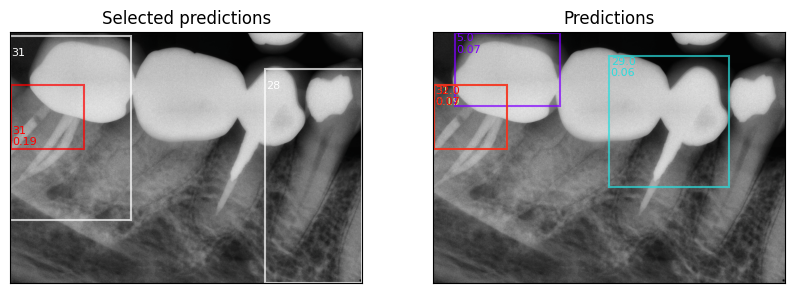

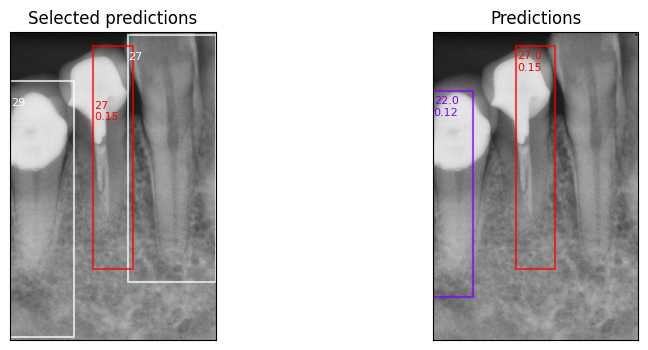

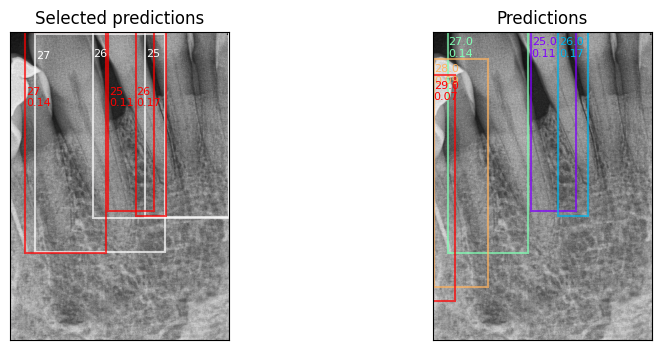

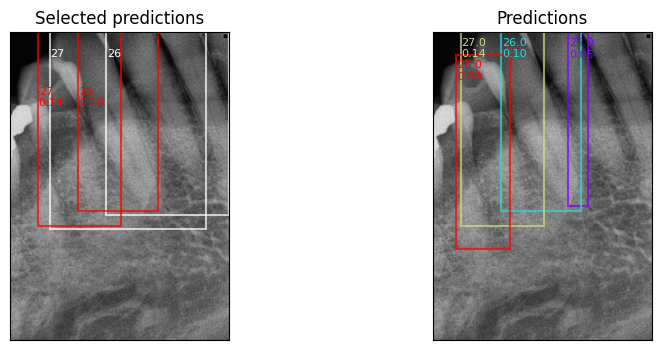

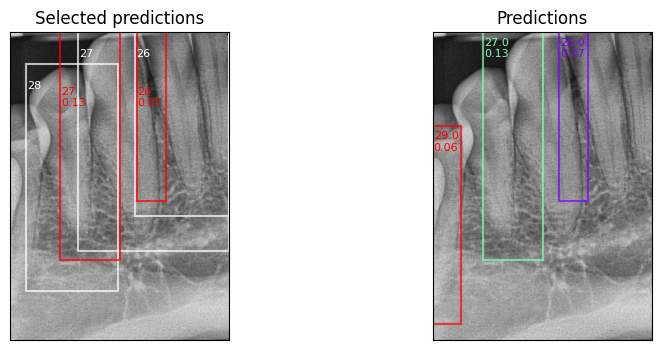

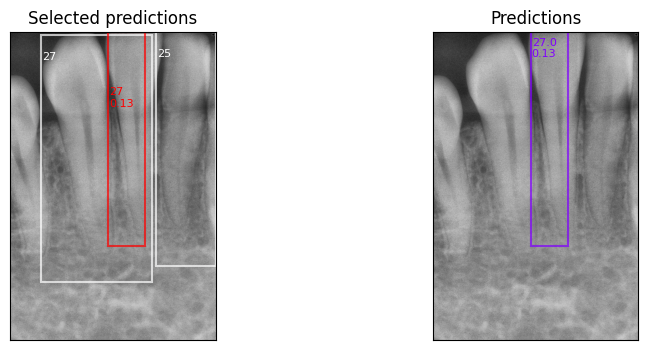

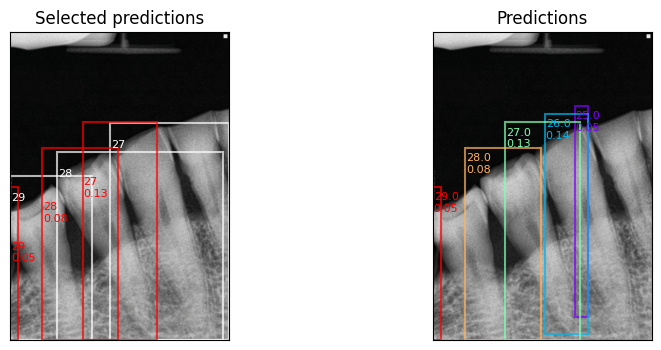

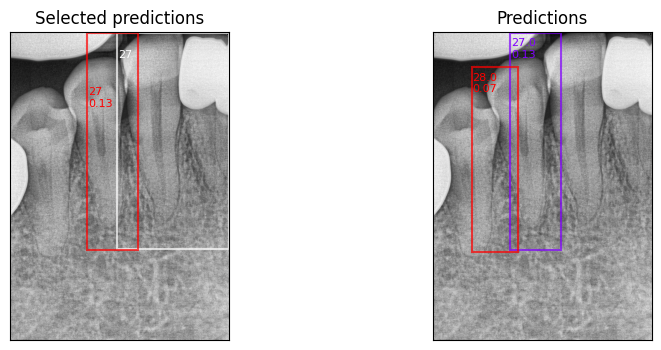

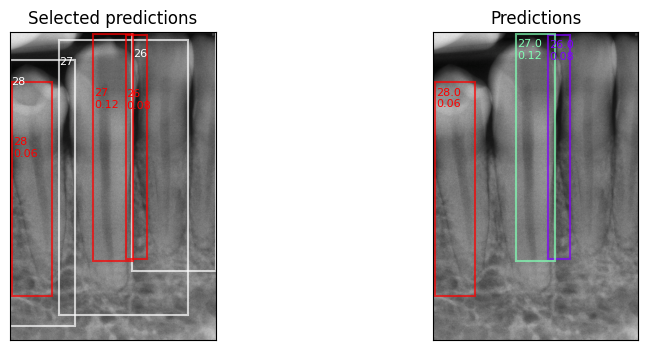

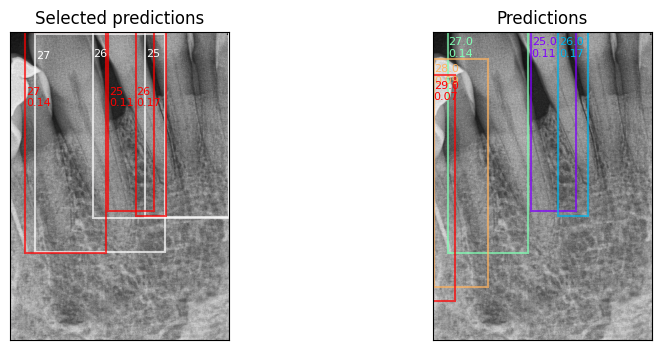

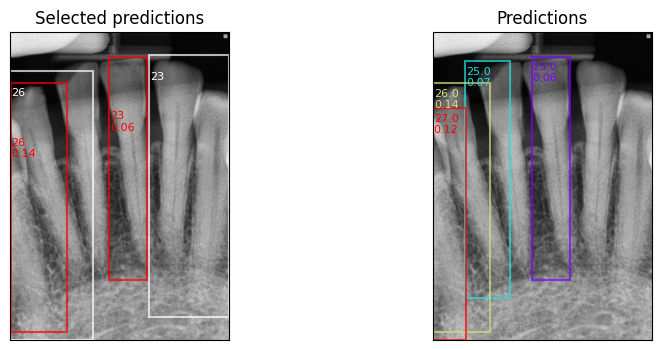

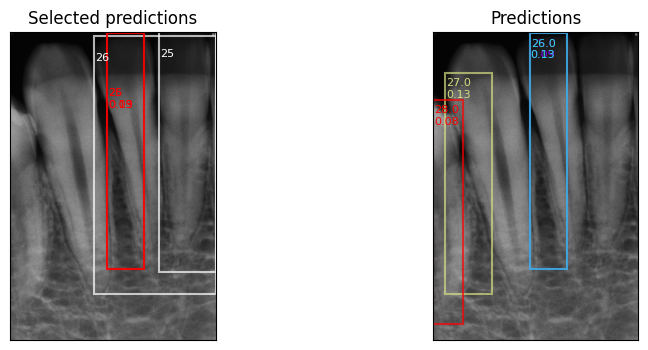

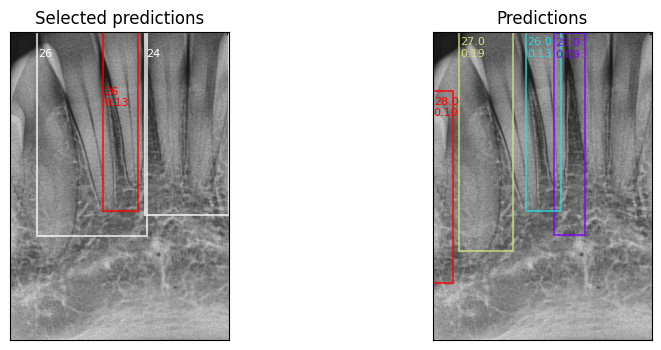

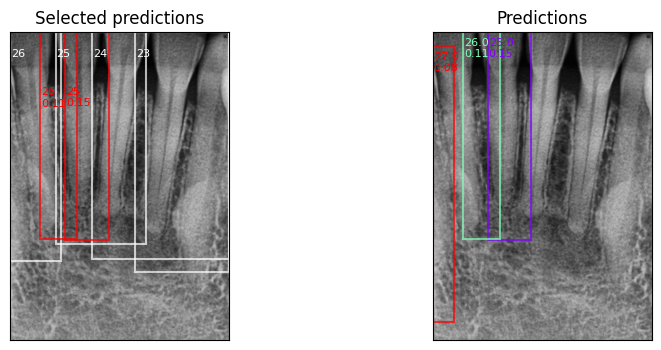

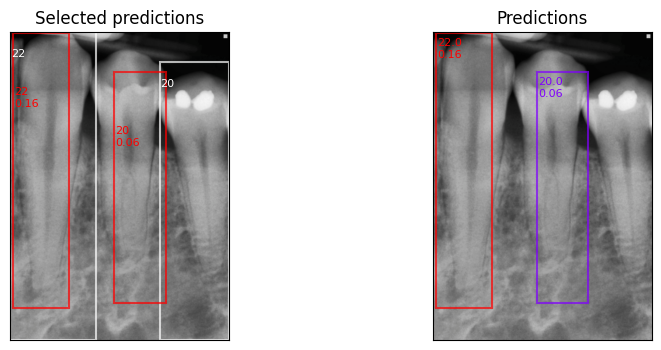

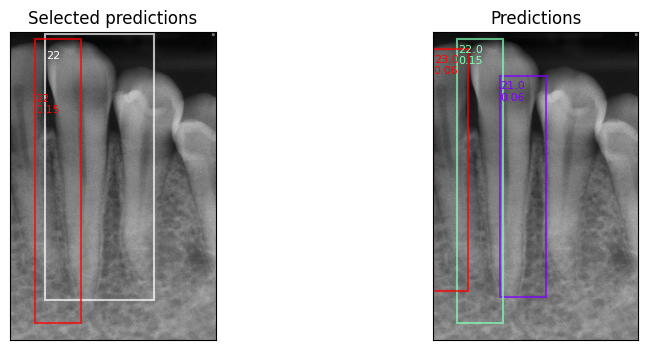

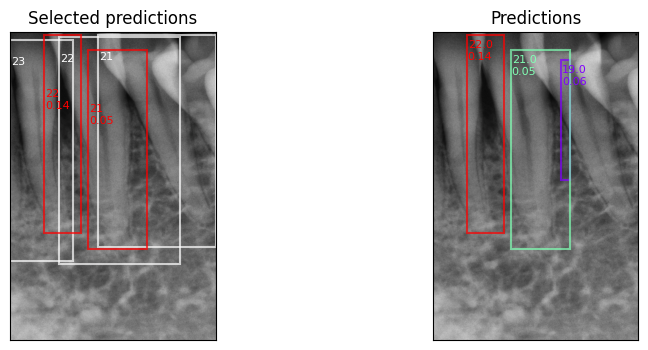

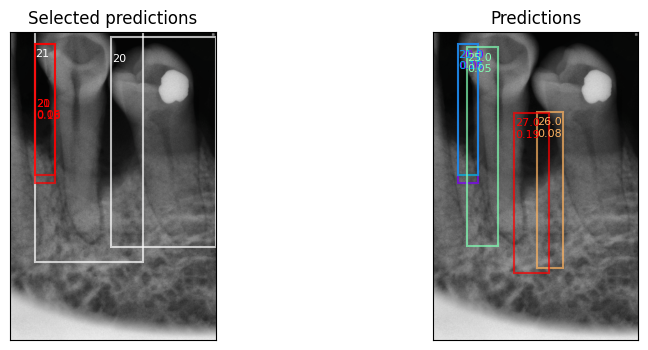

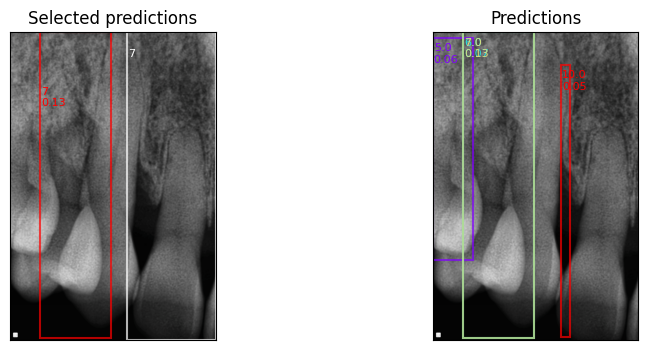

In [12]:
for idx, file_name in enumerate(images):

    # Create a name for the figure
    figure_name = f'{model_name}_{checkpoint_number}_{idx}.png'
    figure_file = os.path.join(image_output_dir, figure_name)
    
    # Load the image
    file = os.path.join(image_dir, file_name)
    im = ImageData().load_image(file)
    im = ImageData().np2color(im)
    im = ImageData().hist_eq(im)
    
    df_file = df.loc[df[file_col] == file_name]
    pos_list = df_file[pos_col].tolist()
    bbox_list = df_file[bbox_col].tolist()
    
    # Matched predictions
    df_file_detected = detected.loc[detected[file_col] == file_name]
    df_file_detected = df_file_detected.\
        sort_values(by=[pos_col, 'score'], ascending=False).\
        groupby(pos_col).first().reset_index(drop=False)
    
    pos_list_detected = df_file_detected[pos_col].tolist()
    scores_detected = df_file_detected['score'].tolist()
    labels_detected = [f'{pos}\n{score:.2f}' for pos, score in zip(pos_list_detected, scores_detected)]
    bbox_list_detected = df_file_detected[bbox_col].tolist()
    
    # All the detections for this image (keep only the predictions with the largest scores)
    df_file_pred = pred_df.loc[pred_df[file_col] == file_name]
    df_file_pred = df_file_pred.\
        sort_values(by=[pos_col, 'score'], ascending=False).\
        groupby(pos_col).first().reset_index(drop=False)
    pos_list_pred = df_file_pred[pos_col].tolist()
    scores_pred = df_file_pred['score'].tolist()
    labels_pred = [f'{pos}\n{score:.2f}' for pos, score in zip(pos_list_pred, scores_pred)]
    bbox_list_pred = df_file_pred[bbox_col].tolist()
    
    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

    # Plot the selected bounding boxes with the ground truth
    # This is the basis for the AP calculation
    
    ax[0] = plot_boxes(image=im, 
                       box_list=bbox_list, 
                       label_list=pos_list, 
                       ax=ax[0],
                       color='w')
    ax[0] = plot_boxes(image=im, 
                       box_list=bbox_list_detected, 
                       label_list=labels_detected, 
                       ax=ax[0],
                       color='r', offset_xy=(0, 200))
    
    ax[0].set(title='Selected predictions')

    # Show all of the predictions
    
    ax[1] = plot_boxes(image=im, box_list=bbox_list_pred, label_list=labels_pred, ax=ax[1])
    ax[1].set(title='Predictions')
    
    plt.savefig(figure_file, bbox_inches='tight')

    plt.show()